## 🕷️ Extract Github Trending Repositories with Official Scrapegraph SDK


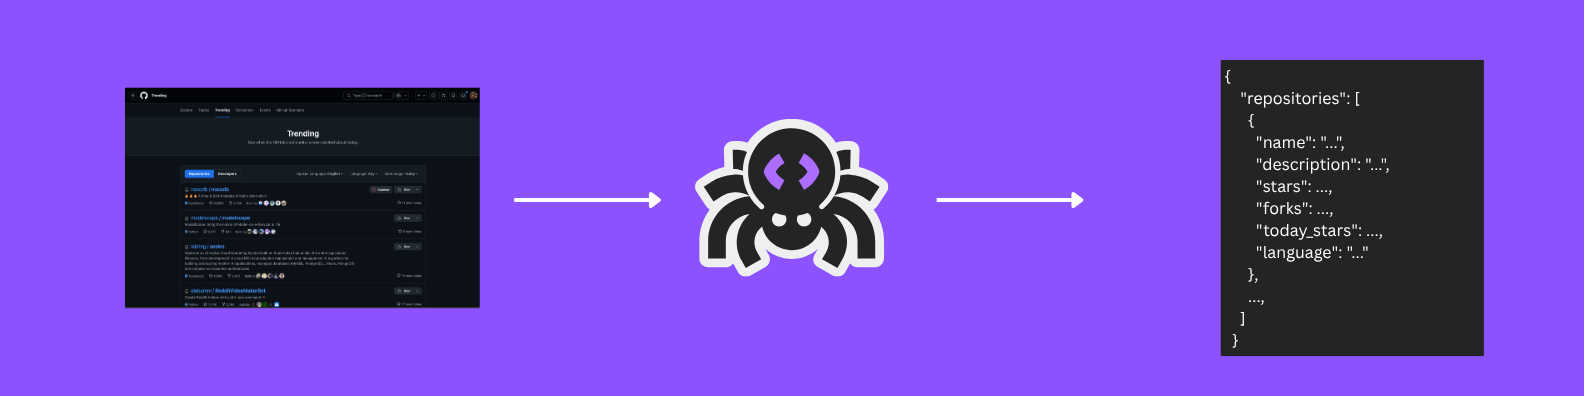

### 🔧 Install `dependencies`

In [1]:
%%capture
!pip install scrapegraph-py

### 🔑 Import `ScrapeGraph` API key

You can find the Scrapegraph API key [here](https://scrapegraphai.com/dashboard)

In [2]:
import getpass
import os

if not os.environ.get("SGAI_API_KEY"):
    os.environ["SGAI_API_KEY"] = getpass.getpass("Scrapegraph API key:\n")

Scrapegraph API key:
 ········


### 📝 Defining an `Output Schema` for Webpage Content Extraction


If you already know what you want to extract from a webpage, you can **define an output schema** using **Pydantic**. This schema acts as a "blueprint" that tells the AI how to structure the response.

<details>
  <summary>Pydantic Schema Quick Guide</summary>

Types of Schemas  

1. Simple Schema  
Use this when you want to extract straightforward information, such as a single piece of content.  

```python
from pydantic import BaseModel, Field

# Simple schema for a single webpage
class PageInfoSchema(BaseModel):
    title: str = Field(description="The title of the webpage")
    description: str = Field(description="The description of the webpage")

# Example Output JSON after AI extraction
{
    "title": "ScrapeGraphAI: The Best Content Extraction Tool",
    "description": "ScrapeGraphAI provides powerful tools for structured content extraction from websites."
}
```

2. Complex Schema (Nested)  
If you need to extract structured information with multiple related items (like a list of repositories), you can **nest schemas**.

```python
from pydantic import BaseModel, Field
from typing import List

# Define a schema for a single repository
class RepositorySchema(BaseModel):
    name: str = Field(description="Name of the repository (e.g., 'owner/repo')")
    description: str = Field(description="Description of the repository")
    stars: int = Field(description="Star count of the repository")
    forks: int = Field(description="Fork count of the repository")
    today_stars: int = Field(description="Stars gained today")
    language: str = Field(description="Programming language used")

# Define a schema for a list of repositories
class ListRepositoriesSchema(BaseModel):
    repositories: List[RepositorySchema] = Field(description="List of GitHub trending repositories")

# Example Output JSON after AI extraction
{
    "repositories": [
        {
            "name": "google-gemini/cookbook",
            "description": "Examples and guides for using the Gemini API",
            "stars": 8036,
            "forks": 1001,
            "today_stars": 649,
            "language": "Jupyter Notebook"
        },
        {
            "name": "TEN-framework/TEN-Agent",
            "description": "TEN Agent is a conversational AI powered by TEN, integrating Gemini 2.0 Multimodal Live API, OpenAI Realtime API, RTC, and more.",
            "stars": 3224,
            "forks": 311,
            "today_stars": 361,
            "language": "Python"
        }
    ]
}
```

Key Takeaways  
- **Simple Schema**: Perfect for small, straightforward extractions.  
- **Complex Schema**: Use nesting to extract lists or structured data, like "a list of repositories."  

Both approaches give the AI a clear structure to follow, ensuring that the extracted content matches exactly what you need.
</details>


In [ ]:
from pydantic import BaseModel, Field
from typing import List

# Schema for Trending Repositories
# This defines only the structure of how a single repository should look like
class RepositorySchema(BaseModel):
    name: str = Field(description="Name of the repository (e.g., 'owner/repo')")
    description: str = Field(description="Description of the repository")
    stars: int = Field(description="Star count of the repository")
    forks: int = Field(description="Fork count of the repository")
    today_stars: int = Field(description="Stars gained today")
    language: str = Field(description="Programming language used")

# Schema that contains a list of repositories
# This references the previous schema
class ListRepositoriesSchema(BaseModel):
    repositories: List[RepositorySchema] = Field(description="List of github trending repositories")

### 🚀 Initialize `SGAI Client` and start extraction

Initialize the client for scraping (an async version using `AsyncScrapeGraphAI` is available [here](https://github.com/ScrapeGraphAI/scrapegraph-py/blob/main/examples/extract/extract_basic_async.py)).

In [4]:
from scrapegraph_py import ScrapeGraphAI

sgai_client = ScrapeGraphAI()

Use the `extract` method to pull structured data from a URL with AI. The same method also accepts raw `html=` or `markdown=` if you already have the page content.

In [5]:
repo_response = sgai_client.extract(
    "Extract only the visible github trending repositories",
    url="https://github.com/trending",
    schema=ListRepositoriesSchema.model_json_schema(),
)

Print the response

In [6]:
import json

if repo_response.status != "success":
    raise RuntimeError(repo_response.error)

result = repo_response.data.json_data

print("Tokens used:", repo_response.data.usage)
print("Trending Repositories:")
print(json.dumps(result, indent=2))

Tokens used: prompt_tokens=45006 completion_tokens=36908
Trending Repositories:
{
  "repositories": [
    {
      "name": "OMNeT++ NED",
      "description": "No content available",
      "stars": 0,
      "forks": 0,
      "today_stars": 0,
      "language": "No content available"
    },
    {
      "name": "OMNeT++ MSG",
      "description": "No content available",
      "stars": 0,
      "forks": 0,
      "today_stars": 0,
      "language": "No content available"
    },
    {
      "name": "ooc",
      "description": "No content available",
      "stars": 0,
      "forks": 0,
      "today_stars": 0,
      "language": "No content available"
    },
    {
      "name": "Opa",
      "description": "No content available",
      "stars": 0,
      "forks": 0,
      "today_stars": 0,
      "language": "No content available"
    },
    {
      "name": "Opal",
      "description": "No content available",
      "stars": 0,
      "forks": 0,
      "today_stars": 0,
      "language": "No content

### 💾 Save the output to a `CSV` file

Let's create a pandas dataframe and show the table with the extracted content

In [17]:
import pandas as pd

# Convert dictionary to DataFrame
df = pd.DataFrame(result["repositories"])
df

,name,description,stars,forks,today_stars,language
0,OMNeT++ NED,No content available,0,0,0,No content available
1,OMNeT++ MSG,No content available,0,0,0,No content available
2,ooc,No content available,0,0,0,No content available
3,Opa,No content available,0,0,0,No content available
4,Opal,No content available,0,0,0,No content available
...,...,...,...,...,...,...
270,playcanvas/supersplat,3D Gaussian Splat Editor,7001,778,579,TypeScript
271,lsdefine/GenericAgent,Self-evolving agent: grows skill tree from 3.3...,10714,1205,174,Python
272,decolua/9router,"Unlimited FREE AI coding. Connect Claude Code,...",7644,1262,803,JavaScript
273,affaan-m/everything-claude-code,The agent harness performance optimization sys...,178795,27573,1081,JavaScript


Save it to CSV

In [8]:
# Save the DataFrame to a CSV file
csv_file = "trending_repositories.csv"
df.to_csv(csv_file, index=False)
print(f"Data saved to {csv_file}")

Data saved to trending_repositories.csv


## 🔗 Resources


- 🚀 **Get your API Key:** [ScrapeGraphAI Dashboard](https://scrapegraphai.com/dashboard)  
- 🐙 **GitHub:** [ScrapeGraphAI GitHub](https://github.com/scrapegraphai)  
- 💼 **LinkedIn:** [ScrapeGraphAI LinkedIn](https://www.linkedin.com/company/scrapegraphai/)  
- 🐦 **Twitter:** [ScrapeGraphAI Twitter](https://twitter.com/scrapegraphai)  
- 💬 **Discord:** [Join our Discord Community](https://discord.gg/uJN7TYcpNa)  

Made with ❤️ by the [ScrapeGraphAI](https://scrapegraphai.com) Team  
